In [1]:
# Uncomment and run this cell if you're on Colab or Kaggle
# !git clone https://github.com/nlp-with-transformers/notebooks.git
# %cd notebooks
# from install import *
# install_requirements(is_chapter7_v2=True)

In [2]:
import haystack
import transformers
import torch

print("Haystack:", haystack.__version__)
print("Transformers:", transformers.__version__)
print("PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

INFO - haystack.document_stores.base -  Numba not found, replacing njit() with no-op implementation. Enable it with 'pip install numba'.
INFO - haystack.modeling.model.optimization -  apex not found, won't use it. See https://nvidia.github.io/apex/
ERROR - root -  Failed to import 'magic' (from 'python-magic' and 'python-magic-bin' on Windows). FileTypeClassifier will not perform mimetype detection on extensionless files. Please make sure the necessary OS libraries are installed if you need this functionality.


Haystack: 1.5.0
Transformers: 4.19.2
PyTorch: 2.0.1+cu118
GPU disponible: True


In [3]:
from utils import *
setup_chapter()

Using transformers v4.19.2
Using datasets v2.1.0


In [4]:
%env TOKENIZERS_PARALLELISM=false

env: TOKENIZERS_PARALLELISM=false


In [5]:
# Suppress Haystack logging
import logging
for module in ["farm.utils", "farm.infer", "haystack.reader.farm.FARMReader",
              "farm.modeling.prediction_head", "elasticsearch", "haystack.eval",
               "haystack.document_store.base", "haystack.retriever.base", 
              "farm.data_handler.dataset"]:
    module_logger = logging.getLogger(module) 
    module_logger.setLevel(logging.ERROR) # Solo quiero ver mensajes de error o críticos.

# Question Answering

<img alt="Marie Curie" width="500" caption="A Google search query and corresponding answer snippet" src="images/chapter07_marie-curie.png" id="marie-curie"/>

## Building a Review-Based QA System

### The Dataset

<img alt="Phone with Query" width="400" caption="A question about a product and the corresponding review (the answer span is underlined)" src="images/chapter07_phone.png" id="phone"/>

In [6]:
from datasets import get_dataset_config_names

#  get_dataset_config_names -> ¿Qué configuraciones (subdatasets) existen?


domains = get_dataset_config_names("subjqa")
domains

['books', 'electronics', 'grocery', 'movies', 'restaurants', 'tripadvisor']

In [7]:
# SubjQA no es un único dataset, sino una colección de varios dominios.

from datasets import load_dataset

subjqa = load_dataset("subjqa", name="electronics") # cargamos sólo el dominio de "electronics"

  0%|          | 0/3 [00:00<?, ?it/s]

In [8]:
print(subjqa["train"]["answers"][1])

{'text': ['Bass is weak as expected', 'Bass is weak as expected, even with EQ
adjusted up'], 'answer_start': [1302, 1302], 'answer_subj_level': [1, 1],
'ans_subj_score': [0.5083333253860474, 0.5083333253860474], 'is_ans_subjective':
[True, True]}


Son columnas anidades porque hay datos dentro de otros datos:
answers contiene un diccionarios y ese diccionario contiene listas

```text
answers
│
├── text
│     ├── "Bass is weak..."
│     └── "Bass is weak..., even with EQ..."
│
├── answer_start
│     ├── 1302
│     └── 1302
│
└── is_ans_subjective
      ├── True
      └── True
```

HF hace esto poruq ealgunso ejemplos tiene una respuesta, otros dos, otro 3...

In [9]:
# Para comprobar el esquema

subjqa["train"].features

{'domain': Value(dtype='string', id=None),
 'nn_mod': Value(dtype='string', id=None),
 'nn_asp': Value(dtype='string', id=None),
 'query_mod': Value(dtype='string', id=None),
 'query_asp': Value(dtype='string', id=None),
 'q_reviews_id': Value(dtype='string', id=None),
 'question_subj_level': Value(dtype='int64', id=None),
 'ques_subj_score': Value(dtype='float32', id=None),
 'is_ques_subjective': Value(dtype='bool', id=None),
 'review_id': Value(dtype='string', id=None),
 'id': Value(dtype='string', id=None),
 'title': Value(dtype='string', id=None),
 'context': Value(dtype='string', id=None),
 'question': Value(dtype='string', id=None),
 'answers': Sequence(feature={'text': Value(dtype='string', id=None), 'answer_start': Value(dtype='int32', id=None), 'answer_subj_level': Value(dtype='int64', id=None), 'ans_subj_score': Value(dtype='float32', id=None), 'is_ans_subjective': Value(dtype='bool', id=None)}, length=-1, id=None)}

In [10]:
# subjqa es un DatasetDict -> estructura separa en train, validation y test.
# cada partición contiene una partición

import pandas as pd

dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}

# subjqa.flatten() -> pasa de nested columns a varias columnas normales
# .items() -> Para que vaya iterando por train, validation y test ->split = train...
# to_pandas() -> Cada Dataset de Hugging Face se convierte en un DataFrame

for split, df in dfs.items(): # Recorre los 3 DF e imprime el número de preguntas 
    print(f"Number of questions in {split}: {df['id'].nunique()}") # .nuniques()-> nº de IDs distintos 

Number of questions in train: 1295
Number of questions in test: 358
Number of questions in validation: 255


**Nombres de las columnas**

- *title*: el ASIN de Amazon de cada producto
- *question*: la pregunta
- *answer.answer_text*: el extracto de texto en la review etiquetada por el anotador
- *answer.answer_start*: el índice del comienzo de la respuesta
- *context*: la review del consumidor

In [11]:
qa_cols = ["title", "question", "answers.text", 
           "answers.answer_start", "context"]
sample_df = dfs["train"][qa_cols].sample(2, random_state=7)
sample_df

,title,question,answers.text,answers.answer_start,context
791,B005DKZTMG,Does the keyboard lightweight?,[this keyboard is compact],[215],I really like this keyboard. I give it 4 stars because it doesn't have a CA...
1159,B00AAIPT76,How is the battery?,[],[],I bought this after the first spare gopro battery I bought wouldn't hold a c...


In [12]:
# Aquí demuestra que las anotaciones del dataset son correctas. 
# Está verificando que el texto almacenado como respuesta coincide exactamente con el fragmento del contexto

start_idx = sample_df["answers.answer_start"].iloc[0][0] # primera fila y primera respuesta de esa fila
end_idx = start_idx + len(sample_df["answers.text"].iloc[0][0]) # calcula dónde termina
sample_df["context"].iloc[0][start_idx:end_idx] # extraemos ese trozo del contexto

'this keyboard is compact'

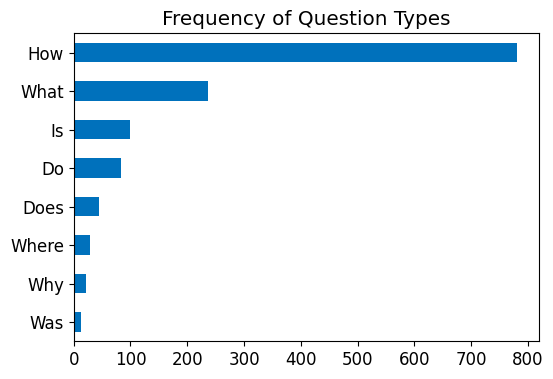

In [13]:
# ¿Con qué palabra empiezan la mayoría de las preguntas del dataset?
counts = {}
question_types = ["What", "How", "Is", "Does", "Do", "Was", "Where", "Why"]

for q in question_types:
    counts[q] = dfs["train"]["question"].str.startswith(q).value_counts()[True] 
    # Guardamos en el diccionario counts el número de preguntas que empiezan por q
    # Añade las claves q al diccionario

pd.Series(counts).sort_values().plot.barh()
# lo convertimos en una serie, lo ordenamosde menor a mayor frecuencia y hacemos un gráfico de barras
plt.title("Frequency of Question Types")
plt.show()

In [14]:
for question_type in ["How", "What", "Is"]:
    for question in (
        dfs["train"][dfs["train"].question.str.startswith(question_type)]
            # .question = ["question"] -> Importante que sea entre comillas -> si no, lo interepreta como
            # [dfs["train"].question.str.startswith(question_type)] -> máscara booleana (True, False)
            # dfs["train"][mascara]
            # igual que pedir = df[df["edad"] > 30]
            

            
        .sample(n=3, random_state=42)['question']):
        print(question)

How is the camera?
How do you like the control?
How fast is the charger?
What is direction?
What is the quality of the construction of the bag?
What is your impression of the product?
Is this how zoom works?
Is sound clear?
Is it a wireless keyboard?


### Sidebar: The Stanford Question Answering Dataset

<img alt="SQuAD SotA" width="600" caption="Progress on the SQuAD 2.0 benchmark (image from Papers with Code)" src="images/chapter07_squad-sota.png" id="squad-sota"/>

### End sidebar

### Extracting Answers from Text

#### Span classification

<img alt="QA Head" caption="The span classification head for QA tasks" src="images/chapter07_qa-head.png" id="qa-head"/>

<img alt="SQuAD models" width="600" caption="A selection of extractive QA models on the Hugging Face Hub" src="images/chapter07_squad-models.png" id="squad-models"/> 

#### Tokenizing text for QA

In [15]:
# Cargamos el tokenizador a partir del modelo/checkpoint
from transformers import AutoTokenizer

model_ckpt = "deepset/minilm-uncased-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [16]:
question = "How much music can this hold?"
context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \
file size."""
inputs = tokenizer(question, context, return_tensors="pt")

In [17]:
#hide_input
# objetivo es visualizar lo que ha producido el tokenizer de una forma cómoda.
input_df = pd.DataFrame.from_dict(tokenizer(question, context), orient="index") 
# no ponemos inputs en lugar de tokenizer(question, context) porque en inputs la salida es como tensor 
# y no es tan limpia para la tabla
input_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
input_ids,101,2129,2172,2189,2064,2023,2907,1029,102,2019,...,2061,2055,25961,2847,5834,2006,5371,2946,1012,102
token_type_ids,0,0,0,0,0,0,0,0,0,1,...,1,1,1,1,1,1,1,1,1,1
attention_mask,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [18]:
# Para ver lo que recibe el modelo

print(tokenizer.decode(inputs["input_ids"][0]))
# inputs["input_ids"] -> Tensor con shape (batch/nume de ejemlos, tokens) -> [0]: 1er y único ejemplo
# tokenizer.decode() -> proceso inverso a tokenización IDs -> Texto

[CLS] how much music can this hold? [SEP] an mp3 is about 1 mb / minute, so
about 6000 hours depending on file size. [SEP]


Aunque la base sea un MiniLM/BERT, la capa de salida es distinta.

```text
Clasificación
    ↓
Devuelve logits para cada clase.

NER
    ↓
Devuelve logits para cada token y cada etiqueta.

Question Answering (QA)
    ↓
Devuelve dos conjuntos de logits:
    • uno para el inicio de la respuesta;
    • otro para el final.
```


In [19]:
import torch
# Cargamos el modelo neuronal entrenado para Question Answering.
from transformers import AutoModelForQuestionAnswering
# instanciamos un modelo -> crear un objeto model con los pesos del checkpoint
model = AutoModelForQuestionAnswering.from_pretrained(model_ckpt) 

# Voy a usar el modelo solo para hacer predicciones. No necesito calcular gradientes.
with torch.no_grad(): # propagación hacia adelante (forward)
    outputs = model(**inputs) 
# ** desempaqueta args -> es comosi hiciérmaos outputs = model(input_ids=inputs["input_ids"],attention_mask=inputs["attention_mask"],token_type_ids=inputs["token_type_ids"]
print(outputs) # así puedo saber las salidas y los nombres de los autputs

QuestionAnsweringModelOutput(loss=None, start_logits=tensor([[-0.9862, -4.7750,
-5.4025, -5.2378, -5.2863, -5.5117, -4.9819, -6.1880,
         -0.9862,  0.2596, -0.2144, -1.7136,  3.7806,  4.8561, -1.0546, -3.9097,
         -1.7374, -4.5944, -1.4278,  3.9949,  5.0391, -0.2018, -3.0193, -4.8549,
         -2.3107, -3.5110, -3.5713, -0.9862]]), end_logits=tensor([[-0.9623,
-5.4733, -5.0326, -5.1639, -5.4278, -5.5151, -5.1749, -4.6233,
         -0.9623, -3.7855, -0.8715, -3.7745, -3.0161, -1.1780,  0.1758, -2.7365,
          4.8934,  0.3046, -3.1761, -3.2762,  0.8937,  5.6606, -0.3623, -4.9554,
         -3.2531, -0.0914,  1.6211, -0.9623]]), hidden_states=None,
attentions=None)


### ¿Qué significa cada número?

Imagina un ejemplo simplificado para una tarea de *Question Answering*.

#### Logits para el inicio de la respuesta (*Start logits*)

```text
Token                 Start logit
---------------------------------
[CLS]                    -3.1
How                      -2.4
much                     -1.7
music                    -0.5
...
6000                      8.2   ← mayor puntuación
hours                     4.3
...
[SEP]                    -5.1
```

El modelo está diciendo:

> "Creo que el token **'6000'** es el mejor candidato para comenzar la respuesta."

---

#### Logits para el final de la respuesta (*End logits*)

```text
Token                 End logit
--------------------------------
...
6000                      5.1
hours                     8.7   ← mayor puntuación
...
```

Aquí el modelo está diciendo:

> "Creo que la respuesta termina en **'hours'**."

---

### Resultado final

El modelo combina ambas predicciones:

```text
Inicio de la respuesta → "6000"
Final de la respuesta  → "hours"
```

Por tanto, la respuesta extraída sería:

```text
6000 hours
```

In [20]:
# Para saber los nombres d elas claves de los outputs
outputs.keys()

odict_keys(['start_logits', 'end_logits'])

In [21]:
# extraemos los dos atributos del objeto outputs
start_logits = outputs.start_logits
end_logits = outputs.end_logits

In [22]:
print(f"Input IDs shape: {inputs.input_ids.size()}")
print(f"Start logits shape: {start_logits.size()}")
print(f"End logits shape: {end_logits.size()}")

Input IDs shape: torch.Size([1, 28])
Start logits shape: torch.Size([1, 28])
End logits shape: torch.Size([1, 28])


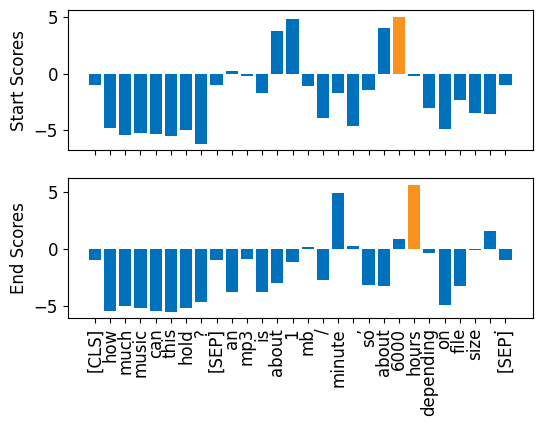

In [23]:
#hide_input
#id qa-scores
#caption Predicted logits for the start and end tokens—the token with the highest score is colored in orange

# The idea for this visualisation comes from https://mccormickml.com/2020/03/10/question-answering-with-a-fine-tuned-BERT
import numpy as np
import matplotlib.pyplot as plt

# Convertimos tensores a numpy array para matplotlib
# antes .detach() -> para crear un tensor desconectado del grafo computacional
# flatten() antes (1, num de tokens) -> (num de tokens,)
s_scores = start_logits.detach().numpy().flatten()
e_scores = end_logits.detach().numpy().flatten()
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]) # convertimos a una lista de tokens. tokenizer.decode() devuelve una cadena de texto
token_ids = range(len(tokens))

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
colors = ["C0" if s != np.max(s_scores) else "C1" for s in s_scores]
ax1.bar(x=token_ids, height=s_scores, color=colors)
ax1.set_ylabel("Start Scores")
colors = ["C0" if s != np.max(e_scores) else "C1" for s in e_scores]
ax2.bar(x=token_ids, height=e_scores, color=colors)
ax2.set_ylabel("End Scores")
plt.xticks(token_ids, tokens, rotation="vertical") # plt.xticks(posiciones, etiquetas)
plt.show()

In [24]:
import torch 

start_idx = torch.argmax(start_logits)  # Devuelve el índice de start_logits con mayor puntuación
end_idx = torch.argmax(end_logits) + 1  # # Devuelve el índice de end_logits con mayor puntuación +1 para que incluya el límite superior
answer_span = inputs["input_ids"][0][start_idx:end_idx] # acotamos el trozo de texto de la respuesta
answer = tokenizer.decode(answer_span) # lo pasamos a tokens
print(f"Question: {question}")
print(f"Answer: {answer}")

Question: How much music can this hold?
Answer: 6000 hours


In [25]:
# Si lo queremos hacer con pipeline
from transformers import pipeline

pipe = pipeline("question-answering", model=model, tokenizer=tokenizer)
pipe(question=question, context=context, topk=3)
#top=3 -> devuélme las 3 mejores respuestas completas

/home/srmjf/qa/lib/python3.9/site-packages/transformers/pipelines/question_answering.py:189: UserWarning: topk parameter is deprecated, use top_k instead
  warnings.warn("topk parameter is deprecated, use top_k instead", UserWarning)


[{'score': 0.2651614844799042, 'start': 38, 'end': 48, 'answer': '6000 hours'},
 {'score': 0.22082993388175964,
  'start': 16,
  'end': 48,
  'answer': '1 MB/minute, so about 6000 hours'},
 {'score': 0.10253530740737915,
  'start': 16,
  'end': 27,
  'answer': '1 MB/minute'}]

In [26]:
pipe(question="Why is there no data?", context=context, 
     handle_impossible_answer=True)

# handle_impossible_answer=True -> Si el modelo cree que no hay respuesta, devuelve una respuesta vacía

{'score': 0.9068413972854614, 'start': 0, 'end': 0, 'answer': ''}

#### Dealing with long passages

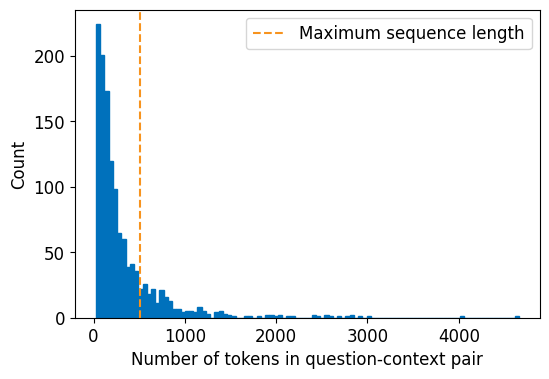

In [27]:
#hide_input
#id subjqa-dist
#caption Distribution of tokens for each question-context pair in the SubjQA training set
def compute_input_length(row):
    inputs = tokenizer(row["question"], row["context"])
    return len(inputs["input_ids"])

dfs["train"]["n_tokens"] = dfs["train"].apply(compute_input_length, axis=1)

fig, ax = plt.subplots()
dfs["train"]["n_tokens"].hist(bins=100, grid=False, ec="C0", ax=ax)
plt.xlabel("Number of tokens in question-context pair")
ax.axvline(x=512, ymin=0, ymax=1, linestyle="--", color="C1", 
           label="Maximum sequence length")
plt.legend()
plt.ylabel("Count")
plt.show()

<img alt="Sliding window" caption="How the sliding window creates multiple question-context pairs for long documents—the first bar corresponds to the question, while the second bar is the context captured in each window" src="images/chapter07_sliding-window.png" id="sliding-window"/>

In [28]:
# Mecanismo de sliding window

# coge la primera fila (1er ejemplo) del conjunto de entrenamiento y dos columnas: question y context
example = dfs["train"].iloc[0][["question", "context"]] 
# Tokeniza -> tokenizer recibe la pareja pregunta + contexto
tokenized_example = tokenizer(example["question"], example["context"], 
                              return_overflowing_tokens=True, max_length=100, 
                              stride=25)
# return_overflowing_tokens=True ->Si el contexto no cabe en una única secuencia, no lo descarta. 
                                    # En su lugar, crea varias secuencias (ventanas).
# max_length=100 -> Cada secuencia podrá tener como máximo 100 tokens.
# stride=25 -> Dos ventanas consecutivas compartirán 25 tokens del contexto.
# Si no cabe todo el contexto en 100 tokens, divídelo en varias ventanas de 100 tokens, 
# haciendo que compartan 25 tokens.

### Antes (`return_overflowing_tokens=False`)

El tokenizador devuelve **un único ejemplo tokenizado**.

```python
tokenized_example = {
    "input_ids": [
        101, 2054, 2003, ..., 102
    ],
    "token_type_ids": [
        0, 0, 0, ..., 1
    ],
    "attention_mask": [
        1, 1, 1, ..., 1
    ]
}
```

---

### Después (`return_overflowing_tokens=True`)

Si el contexto es demasiado largo, el tokenizador lo divide en varias **ventanas** (*sliding windows*).

Ahora cada campo contiene **una lista de ventanas**, en lugar de una única secuencia.

```python
tokenized_example = {
    "input_ids": [
        [ ... ventana 1 ... ],
        [ ... ventana 2 ... ],
        [ ... ventana 3 ... ],
        ...
    ],

    "token_type_ids": [
        [ ... ventana 1 ... ],
        [ ... ventana 2 ... ],
        [ ... ventana 3 ... ],
        ...
    ],

    "attention_mask": [
        [ ... ventana 1 ... ],
        [ ... ventana 2 ... ],
        [ ... ventana 3 ... ],
        ...
    ],

    "overflow_to_sample_mapping": [
        0, 0, 0, ...
    ]
}
```
"overflow_to_sample_mapping": Indica el ejemplo del que proviene
---

### Esquema conceptual

```text
Ejemplo original
        │
        ▼
┌──────────────────────────────────────────┐
│ Pregunta + Contexto muy largo            │
└──────────────────────────────────────────┘
        │
        ▼
El tokenizer divide el contexto en ventanas
        │
        ▼
┌───────────┐
│ Ventana 1 │
└───────────┘
┌───────────┐
│ Ventana 2 │
└───────────┘
┌───────────┐
│ Ventana 3 │
└───────────┘
        │
        ▼
Cada ventana tiene sus propios:
• input_ids
• token_type_ids
• attention_mask
• overflow_to_sample_mapping



```

**overflow_to_sample_mapping** indica de qué ejemplo original proviene cada ventana.


In [29]:
for idx, window in enumerate(tokenized_example["input_ids"]):
    print(f"Window #{idx} has {len(window)} tokens")

Window #0 has 100 tokens
Window #1 has 88 tokens


In [30]:
for window in tokenized_example["input_ids"]:
    print(f"{tokenizer.decode(window)} \n")

[CLS] how is the bass? [SEP] i have had koss headphones in the past, pro 4aa and
qz - 99. the koss portapro is portable and has great bass response. the work
great with my android phone and can be " rolled up " to be carried in my
motorcycle jacket or computer bag without getting crunched. they are very light
and don't feel heavy or bear down on your ears even after listening to music
with them on all day. the sound is [SEP]

[CLS] how is the bass? [SEP] and don't feel heavy or bear down on your ears even
after listening to music with them on all day. the sound is night and day better
than any ear - bud could be and are almost as good as the pro 4aa. they are "
open air " headphones so you cannot match the bass to the sealed types, but it
comes close. for $ 32, you cannot go wrong. [SEP]



```text
                    Ejemplo original
┌──────────────────────────────────────────────────────────────┐
│ Pregunta: How much music can this hold?                      │
│ Contexto: An MP3 is about 1 MB per minute... (muy largo)     │
└──────────────────────────────────────────────────────────────┘
                             │
                             ▼
             El tokenizer crea ventanas solapadas
                             │
                             ▼

┌──────────────────────────────────────────────────────────────┐
│ [CLS] How much music can this hold? [SEP]                    │
│ An MP3 is about 1 MB per minute...                           │
│ ...                                                          │
└──────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────┐
│ [CLS] How much music can this hold? [SEP]                    │
│ ... últimos 25 tokens de la ventana anterior ...             │
│ ...                                                          │
└──────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────┐
│ [CLS] How much music can this hold? [SEP]                    │
│ ...                                                          │
└──────────────────────────────────────────────────────────────┘
```

### Using Haystack to Build a QA Pipeline

<img alt="QA Architecture" caption="The retriever-reader architecture for modern QA systems" src="images/chapter07_retriever-reader.png" id="retriever-reader"/>

#### Initializing a document store

In [93]:
# descarga e instala Elasticsearch de forma local

# URL de descarga
url = """https://artifacts.elastic.co/downloads/elasticsearch/\
elasticsearch-7.9.2-linux-x86_64.tar.gz""" # versión 7.9.2
!wget -nc -q {url}
# equivale a abrir un terminal y escribir wget -nc -q https://... donde:
    # wget → Utilidad de Linux para descargar archivos desde internte
    # -q → quiet (no mostrar mensajes).
    # -nc → no clobber. Si el archivo ya existe, no vuelve a descargarlo.

!tar -xzf elasticsearch-7.9.2-linux-x86_64.tar.gz
# tar es una utilidad de Unix/Linux para agrupar y extraer archivos
# El archivo que descargué tiene dos formatos combinados:
    # .tar -> un único archivo que contiene muchos archivos y carpetas, como un contenedor.
    # .gz -> Ese contenedor se comprime con gzip.
    # -xzf
        # x-> eXtract
        # z-> el archivo está comprido con gzip
        # f-> siguiente argumento es el nombre del archivo


ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [94]:
# Arrancamos el servidor Elasticsearch

import os # funciones relacionadas con el sistema operativo (archivos, procesos, variables de entorno, etc.).
import time # utilidades relacionadas con el tiempo.
from subprocess import Popen, PIPE, STDOUT
# Popen _> es una clase de Python que crea y controla un proceso del sistema operativo
# Un proceso es un programa que se está ejecutando
# lanzamos elasticsearch
es_server = Popen(
    ["elasticsearch-7.9.2/bin/elasticsearch"],
    stdout=PIPE, # Todos los programas escriben información por la salida estándar (stdout). 
                 # Esta salida no se imprime sino que se guarda en una tubería (pipe) para que Python pueda leerla 
    stderr=STDOUT, # hay dos salidas: estandar (stdout) y mensajes de error. Aquí juntamos ambas salidas
    # stdout es un parámetro
    # STDOUT es una constante definida en el módulo subprocess
    text=True # para no recibir por defectos como bytes sino como texto
)

time.sleep(30) # Elasticsearch tarda unos segundos en arrancar. Si no el servidor puede fallar

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


# Alternative if Docker is installed
from haystack.utils import launch_es

launch_es()

In [95]:
# Para comprobar que elasticsearch funciona

!curl -X GET "localhost:9200/?pretty"
# curl herramienta para hacer peticiones HTTP (un navegador muy simple)
# -GET -> especifica el método HTTP -> GET -> Quiero obtener información

curl: (7) Failed to connect to localhost port 9200 after 0 ms: Couldn't connect to server


In [97]:
# Iniciar el document store

from haystack.document_stores.elasticsearch import ElasticsearchDocumentStore

# Return the document embedding for later use with dense retriever 
document_store = ElasticsearchDocumentStore(return_embedding=True)
# crear un objeto Python que sabe hablar con Elasticsearch
# return_embedding=True -> Cuando recuperes documentos, devuelve también su embedding.

Haystack soporta varios tipos de Document Store:

- Elasticsearch
- FAISS
- SQL
- InMemory
- Pinecone
- etc.

Aquí eliges el basado en Elasticsearch.

In [98]:
# Esta celda es una medida de seguridad para que cada vez que ejecutes 
# el notebook empieces con una base de datos limpia.

# It's a good idea to flush Elasticsearch with each notebook restart
if len(document_store.get_all_documents()) or len(document_store.get_all_labels()) > 0:
    document_store.delete_documents(index="document")
    document_store.delete_documents(index="label")

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


Since version 1.0 of Haystack, Documents now have a field `content`, which replaces the field `text`. This change was introduced because Documents have become more flexible and can also store tables in addition to texts.

### Recordemos la estructura que devuelve `subjqa["train"].features`

```text
subjqa["train"].features
│
├── domain : string
├── nn_mod : string
├── nn_asp : string
├── query_mod : string
├── query_asp : string
├── q_reviews_id : string
├── question_subj_level : int64
├── ques_subj_score : float32
├── is_ques_subjective : bool
├── review_id : string
├── id : string
├── title : string
├── context : string
├── question : string
└── answers
      │
      ├── text : string[]
      ├── answer_start : int32[]
      ├── answer_subj_level : int64[]
      ├── ans_subj_score : float32[]
      └── is_ans_subjective : bool[]
```

> **Nota:** `answers` es un campo de tipo **Sequence**, por lo que cada ejemplo puede contener **cero, una o varias respuestas**, almacenadas como listas paralelas (una lista para los textos, otra para las posiciones de inicio, etc.).

In [116]:
# Esta celda es donde se transforman las filas del dataset en documentos de Haystack y se guardan en Elasticsearch.
# Recordemos que antes ya teníamos:
# dfs = {split: dset.to_pandas() for split, dset in subjqa.flatten().items()}


for split, df in dfs.items():
    # Exclude duplicate reviews
    docs = [{"content": row["context"], "id": row["review_id"],
             "meta":{"item_id": row["title"], "question_id": row["id"], 
                     "split": split}} 
        for _,row in df.drop_duplicates(subset="context").iterrows()]
    # se genera un docuemnto por cada fila que queda después de eliminar los contextos duplicados
    
    document_store.write_documents(documents=docs, index="document")
    # guarda todos los documentos en el Document Store (Elasticsearch)
    # index="document" -> nombre arbitrario para indexar cada documento: document 1, document 2...
    
# df.drop_duplicates(subset="context") -> Elimina las filas que tengan el mismo valor en la columna context.
# .iterrows() -> devuelve índice de la fila "_"  y contenido de la fila "row"
print(f"Loaded {document_store.get_document_count()} documents")

Loaded 1615 documents


#### Initializing a retriever

In Haystack 1.4 `ElasticsearchRetriever` was renamed to `BM25Retriever`. You can still use `ElasticsearchRetriever` for compatibility reasons in version 1.5 but it might be removed in future releases.

BM25 _> este algoritmo: compara
- las palabras de la pregunta
- las palabras de cada documento.

In [38]:
from haystack.nodes.retriever import BM25Retriever

bm25_retriever = BM25Retriever(document_store=document_store) # creamos el retriever 
# y le decimos que los docs están en docuemnt_store

In [39]:
item_id = "B0074BW614"
query = "Is it good for reading?" # Pregunta del usuario
retrieved_docs = bm25_retriever.retrieve(
    query=query, top_k=3, filters={"item_id":[item_id], "split":["train"]})

# top_k=3 Devuélveme los 3 docs más relevantes
# filters ={...}. Los filtros actúan sobre los metadatos ("meta") de los datos añadidos
# Busca solo documentos del producto B0074BW614 en el conjunto de entrenamiento

In [40]:
 print(retrieved_docs[0].content) # contenido del primero de los 3 mejores docs

This is a gift to myself.  I have been a kindle user for 4 years and this is my
third one.  I never thought I would want a fire for I mainly use it for book
reading.  I decided to try the fire for when I travel I take my laptop, my phone
and my iPod classic.  I love my iPod but watching movies on the plane with it
can be challenging because it is so small. Laptops battery life is not as good
as the Kindle.  So the Fire combines for me what I needed all three to do. So
far so good.


In [41]:
print(retrieved_docs[0].meta) # su meta

{'__pydantic_initialised__': True, 'item_id': 'B0074BW614', 'question_id':
'868e311275e26dbafe5af70774a300f3', 'split': 'train'}


In [42]:
print(retrieved_docs[0].score) #su puntuación

0.6857824513476455


#### Initializing a reader

In [43]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.memory_allocated(0) / 1024**3)
print(torch.cuda.memory_reserved(0) / 1024**3)

True
NVIDIA GeForce RTX 4080 Laptop GPU
0.0
0.0


In [44]:
from haystack.nodes import FARMReader

model_ckpt = "deepset/minilm-uncased-squad2" #alternative larger models: deepset/roberta-base-squad2-distilled or deepset/xlm-roberta-large-squad2 or the tiny distilled model: deepset/tinyroberta-squad2
# ëste es el modelo que va a cusar el Reader -> Modelo de HF entrenado para QA

max_seq_length, doc_stride = 384, 128 # tamañao máximo de secuencia y de solapamiento

# creamos el reader
reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride, 
                    return_no_answer=True, use_gpu=True,num_processes=0)
# return_no_answer=True -> Permite que el modelo diga no encuentro respuesta en este documento
# OJO!!! He añadido num_processes=0 para que vaya más rápido

INFO - haystack.modeling.utils -  Using devices: CUDA:0
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.model.language_model -  LOADING MODEL
INFO - haystack.modeling.model.language_model -  =============
INFO - haystack.modeling.model.language_model -  Could not find deepset/minilm-uncased-squad2 locally.
INFO - haystack.modeling.model.language_model -  Looking on Transformers Model Hub (in local cache and online)...
INFO - haystack.modeling.model.language_model -  Loaded deepset/minilm-uncased-squad2
INFO - haystack.modeling.utils -  Using devices: CUDA
INFO - haystack.modeling.utils -  Number of GPUs: 1


In [45]:
print(reader.predict_on_texts(question=question, texts=[context], top_k=1))
# recordemos que 
    # question = "How much music can this hold?"
    # context = """An MP3 is about 1 MB/minute, so about 6000 hours depending on \


{'query': 'How much music can this hold?', 'no_ans_gap': 12.648086905479431,
'answers': [<Answer {'answer': '6000 hours', 'type': 'extractive', 'score':
0.5293052941560745, 'context': 'An MP3 is about 1 MB/minute, so about 6000 hours
depending on file size.', 'offsets_in_document': [{'start': 38, 'end': 48}],
'offsets_in_context': [{'start': 38, 'end': 48}], 'document_id':
'e344757014e804eff50faa3ecf1c9c75', 'meta': {}}>]}


#### Putting it all together

In [46]:
# unimos el retriever y el reader en una sola pipeline

from haystack.pipelines import ExtractiveQAPipeline

pipe = ExtractiveQAPipeline(reader=reader, retriever=bm25_retriever)

The format of parameters that can be passed to a pipeline has slightly changed. In the old version, the method call was 
```python
preds = pipe.run(query=query, top_k_retriever=3, top_k_reader=n_answers,
                 filters={"item_id": [item_id], "split":["train"]})
```
Now, you can specify the name of the node, e.g., `"Retriever"`, that you want to pass parameters to.

In [47]:
n_answers = 3 # el reader devolverá como máximo 3 respuestas
preds = pipe.run(
    query=query, 
    params={
        "Retriever": {
            "top_k": 3, # retriver busca los 3 docs más relevantes
            "filters":{
                "item_id": [item_id], # sólo busca docs con producto seleccionado
                "split":["train"] # que el split sea train
            }
        }, 
                                     
        "Reader": {"top_k": n_answers # el reader analiza esos docs y devuelve hasta 3 respuestas
                  }
    }
)

print(f"Question: {preds['query']} \n") # muestra query procesada

for idx in range(n_answers):
    print(f"Answer {idx+1}: {preds['answers'][idx].answer}")
    print(f"Review snippet: ...{preds['answers'][idx].context}...")
    print("\n\n")


# preds es un diccionario, que devuelve la pipeline de HayStack- La estructura general es:
# preds = {
#    "query": str,
#    "answers": List[Answer],
#}

Question: Is it good for reading?

Answer 1: it is great for reading books when no light is available
Review snippet: ...ecoming addicted to hers! Our son LOVES it and it is great
for reading books when no light is available. Amazing sound but I suggest good
headphones t...



Answer 2: I mainly use it for book reading
Review snippet: ... is my third one.  I never thought I would want a fire for I
mainly use it for book reading.  I decided to try the fire for when I travel I
take my la...



Answer 3:
Review snippet: ...None...





## Improving Our QA Pipeline

### Evaluating the Retriever

La idea general de este bloque es:

1. Crear una pipeline que solo tenga el Retriever
2. Crear las respuestas correctas de referencia: los Labels
3. Guardarlas
4. Agruparlas
5. Ejecutar la evaluación
6. Calcular el recall

Evaluating the retriever is the same as evaluating a `DocumentSearchPipeline`, which consists only of a single node, a retriever.

In [48]:
from haystack.pipelines import DocumentSearchPipeline

# Creamos pipeline del retriever

pipe = DocumentSearchPipeline(retriever=bm25_retriever)

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


### Evaluación del *retriever*

En este caso, quieren evaluar únicamente esta parte del sistema:

```text
Pregunta
   │
   ▼
Retriever
   │
   ▼
Documentos recuperados
```

`DocumentSearchPipeline` es un *pipeline* que contiene únicamente un `Retriever`.

---

### ¿Qué necesita Haystack para evaluarlo?

Haystack necesita conocer de antemano cuál es el resultado correcto.

Supongamos esta pregunta:

```text
How does the fan work?
```

El *retriever* devuelve tres reseñas.

Para determinar si ha recuperado los documentos adecuados, Haystack necesita saber:

- cuál era la respuesta correcta;
- en qué reseña aparecía;
- a qué producto pertenecía;
- qué filtros debían utilizarse.

Toda esta información se guarda en objetos llamados `Label`.

---

### ¿Qué es un `Label`?

Un `Label` representa el resultado correcto de referencia, también llamado *ground truth*.

Su estructura conceptual sería:

```python
Label(
    pregunta="How does the fan work?",
    respuesta_correcta="the fan is really good",
    documento_correcto="reseña donde aparece esa respuesta",
    producto="B002MU1ZRS"
)
```

Conceptualmente:

```text
Label
│
├── Pregunta
│     └── "How does the fan work?"
│
├── Respuesta correcta
│     └── "the fan is really good"
│
├── Documento correcto
│     └── Reseña donde aparece la respuesta
│
└── Producto o filtro
      └── "B002MU1ZRS"
```

Haystack compara los documentos recuperados por el `Retriever` con la información almacenada en estos `Label` para calcular sus métricas de evaluación.


Since version 1.0 of Haystack, `Answer` has become a class and each `Label` contains a `Document` that the `Label` refers to. Thus, the initialization of a `Label` in the following code cell has changed.
Note that the code printed in the book had a small bug. In the for loop of the old code, `Label`s were created that were all initialized with the same id. Thus they were handled as duplicates and not all of them were stored in the document store when we later on called `document_store.write_labels(labels, index="label")`:
```python
for answer in row["answers.text"]:
            label = Label(
                question=row["question"], answer=answer, id=i, origin=row["id"],
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False)
            labels.append(label)
```


*In the previous version there was a bug that omitted some of the labels.*

In [49]:
from haystack import Label, Answer, Document

# se importan 3 tipos de objetos:
    # answer: Representan una respuesta
        # Answer(answer="the fan is really good")
    # document: el documento o reseña que contiene esa respuesta 
        # Document(content=row["context"],id=row["review_id"])
    #Label: Une todo: pregunta (query), respuesta correcta (answer), doc correcto (Document), metadatos y filtros
    

labels = [] # Lista vacía donde se irán guardando todos los labels
for i, row in dfs["test"].iterrows(): # recorre cojunto de test, Cada row: fila del dataset
    # cada row tiene distintos campos:
        #row["question"]
        #row["context"]
        #row["answers.text"]...
    # Creamos los metadatos
    # Metadata used for filtering in the Retriever
    meta = {"item_id": row["title"], "question_id": row["id"]}
    # en este dataset title contiene el identificador del producto
    # Populate labels for questions with answers
    if len(row["answers.text"]): # comporbamos si la pregunta tiene respuesta
        for answer in row["answers.text"]:
            label = Label(
                query=row["question"], answer=Answer(answer=answer), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
                meta=meta, is_correct_answer=True, is_correct_document=True,
                no_answer=False, filters={"item_id": [meta["item_id"]], "split":["test"]})
                #origin="gold-label" -> indica que label es una referencia correcta proporcionada por el dataset
                #Answer(answer=answer)
                    #Answer() -> clase de Haystack
                    #answer= -> nombre del parámetro de esa clase
                    #answer es la variable creada por el for
                #is_correct_answer=True -> Indica que la respuesta guardada es correcta.
                #is_correct_document=True -> Indica que el documento guardado es uno de los documentos correctos.
                #no_answer=False -> Esta pregunta sí tiene respuesta
            labels.append(label)
    # Populate labels for questions without answers
    else: # si no tiene respuesta
        label = Label(
            query=row["question"], answer=Answer(answer=""), origin="gold-label", document=Document(content=row["context"], id=row["review_id"]),
            meta=meta, is_correct_answer=True, is_correct_document=True,
            no_answer=True, filters={"item_id": [row["title"]], "split":["test"]})  
            # igual que antes pero como no hay repuesta:
                # answer=Answer(answer="")
                # no_answer=True
        
        labels.append(label)

### Para evaluar el `Retriever` necesitamos un solucionario

Cada `Label` es una entrada de ese solucionario:

```text
Label
│
├── Pregunta
├── Respuesta correcta
├── Documento correcto
└── Filtros
```

Es decir:

```text
Pregunta
+ respuesta correcta
+ documento correcto
+ filtros
```

In [50]:
# simplemente guarda ese solucionario en Elasticsearch.

document_store.write_labels(labels, index="label")

print(f"""Loaded {document_store.get_label_count(index="label")} \
question-answer pairs""")

#labels no contiene predicciones. 
#labels contiene la verdad de referencia con la que después se juzgará al retriever.

Loaded 455 question-answer pairs


In [51]:
# agrega las etiquetas por item_id para no mezclar preguntas de productos distintos
labels_agg = document_store.get_all_labels_aggregated(
    index="label",
    open_domain=True,
    aggregate_by_meta=["item_id"]
)
print(len(labels_agg)) # ahora contamos preguntas, antes respuestas

330


Since version 1.0 of Haystack, the evaluation of pipelines is much different compared to the version described in the first edition of the book. `Pipeline` now has a method `eval()`, which runs the pipeline given input data from labels and returns the prediction and the labels in the format of one Pandas dataframe per pipeline node. This result is stored in `eval_result` in the following code cell. On these results, we can calculate arbitrary metrics - without rerunning the computationally intesive inference steps of the pipeline.

In [52]:
pipe

In [53]:
# We can run the pipeline with the desired top_k value like this
# Esta celda hace la evaluación real del retriever.

eval_result = pipe.eval(
    labels=labels_agg, # entrega a eval() el solucionario agrupado
    params={"Retriever": {"top_k": 3}}, # el componente "Retriever" debe devolver los 3 docs mejor clasificados
)

# eval() recorre los MultiLabel de labels_agg.
# Para cada pregunta, aproximadamente hace esto:
    #1. Coge la pregunta del MultiLabel.
    #2. Coge sus filtros.
    #3. Ejecuta el Retriever.
    #4. Recupera los 3 primeros documentos.
    #5. Compara esos documentos con el documento correcto del MultiLabel.
    #6. Guarda el resultado.

metrics = eval_result.calculate_metrics()

# Toma todos los resultados anteriores y calcula las métricas agregadas. 
# pasa de:
    #Pregunta 1: acierto
    #Pregunta 2: acierto
    #Pregunta 3: fallo
    #Pregunta 4: acierto
    #...
# a:
    #{
     #   "Retriever": {
      #      "recall_single_hit": 0.96,
       #     ...
        #}
    #}


ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [54]:
print(f"Recall@3: {metrics['Retriever']['recall_single_hit']:.2f}")

Recall@3: 0.96


You can check the predictions of any query by inspecting the dataframe:

In [55]:
eval_df = eval_result["Retriever"]
eval_df[eval_df["query"] == "How do you like the lens?"][["query", "filters", "rank", "context", "gold_contexts", "document_id", "gold_document_ids", "gold_id_match"]]

,query,filters,rank,context,gold_contexts,document_id,gold_document_ids,gold_id_match
0,How do you like the lens?,"b'{""item_id"": [""B00006I53S""], ""split"": [""test""]}'",1.0,I bought this lens for my Canon 20D digital camera and have found it to be a...,[I bought this lens for my Canon 20D digital camera and have found it to be ...,fac2e8bec06035a70307dd1e8034ea63,[fac2e8bec06035a70307dd1e8034ea63],1.0
1,How do you like the lens?,"b'{""item_id"": [""B00006I53S""], ""split"": [""test""]}'",2.0,I am not a professional or expert photographer...so take these comments with...,[I bought this lens for my Canon 20D digital camera and have found it to be ...,26bf35fe7f9a73d28535d5072ab17714,[fac2e8bec06035a70307dd1e8034ea63],0.0
0,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",1.0,I think that the title says it all. It is one of the cheapest lens on the ma...,[],9cae133919a2dc476c371cde9e5effb8,[],0.0
1,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",2.0,I bough this lens for a relative who bought my old canon rebel xti from me (...,[],a1f6e39766a79f1475b3dbe07e517e04,[],0.0
2,How do you like the lens?,"b'{""item_id"": [""B00007E7JU""], ""split"": [""test""]}'",3.0,"I fell in love with the lens the moment I started using it. sure, the build ...",[],0fc71a2e4ec350e845ed384717792ad8,[],0.0
0,How do you like the lens?,"b'{""item_id"": [""B0025EWXEU""], ""split"": [""test""]}'",1.0,"I have read a lot of negative press about this lens, but I have to tell you ...","[I have read a lot of negative press about this lens, but I have to tell you...",47f76b8f62cf296d394d993741d660aa,"[47f76b8f62cf296d394d993741d660aa, 47f76b8f62cf296d394d993741d660aa]",1.0


Or if we want to calculate metrics for multiple topk values, we can run the pipeline only once with the highest top_k value and calculate metrics for smaller top_ks afterwards.

No hace falta volver a evaluar el Retriever para cada top_k.

Solo se ejecuta una vez con el top_k más grande y después se calculan las métricas para los top_k pequeños reutilizando los resultados.

In [56]:
def evaluate_retriever(retriever, topk_values = [1,3,5,10,20]):
    topk_results = {}
    # Calculate max top_k
    max_top_k = max(topk_values)
    # Create Pipeline
    p = DocumentSearchPipeline(retriever=retriever)
    # Run inference with max top_k by looping over each question-answers pair in test set
    eval_result = p.eval(
        labels=labels_agg,
        params={"Retriever": {"top_k": max_top_k}}, # calcula la evaluación para el top k máximo (20)
    )
    # Calculate metric for each top_k value
    for topk in topk_values:        
        # Get metrics
        metrics = eval_result.calculate_metrics(simulated_top_k_retriever=topk)
        topk_results[topk] = {"recall": metrics["Retriever"]["recall_single_hit"]} # guarda el recall
        
    return pd.DataFrame.from_dict(topk_results, orient="index")


bm25_topk_df = evaluate_retriever(bm25_retriever)

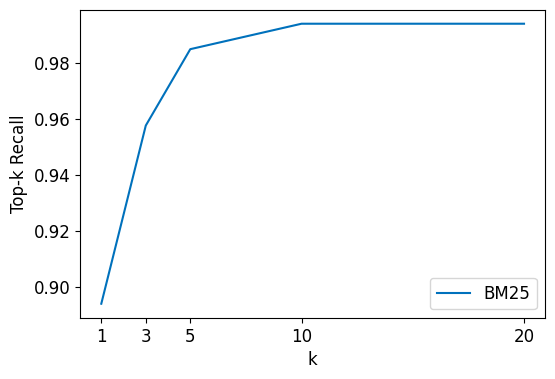

In [57]:
# Sólo dibuja la gráfica con los resultados que calculaste en la función anterior.

def plot_retriever_eval(dfs, retriever_names):
    #dfs -> Una lista de DataFrames.
    #retriever_names -> nombres que aparecerán en la leyenda
    fig, ax = plt.subplots()
    for df, retriever_name in zip(dfs, retriever_names):
        df.plot(y="recall", ax=ax, label=retriever_name) # recall lo definimos en la celda anterior
    plt.xticks(df.index)
    plt.ylabel("Top-k Recall")
    plt.xlabel("k")
    plt.show()
    
plot_retriever_eval([bm25_topk_df], ["BM25"])

#### Dense Passage Retrieval

<img alt="DPR Architecture" caption="DPR's bi-encoder architecture for computing the relevance of a document and query" src="images/chapter07_dpr.png" id="dpr"/>

In [58]:
from haystack.nodes import DensePassageRetriever

dpr_retriever = DensePassageRetriever(document_store=document_store,
    query_embedding_model="facebook/dpr-question_encoder-single-nq-base",
    passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base",
    embed_title=False)

# query_embedding_model="facebook/dpr-question_encoder-single-nq-base" -> Xa convert 1 pregunta en embedding: este modelo.
    # este modelo está entrenado sólo para preguntas, no para documentos

# passage_embedding_model="facebook/dpr-ctx_encoder-single-nq-base"-> Xa convert reseñas en embeddings


INFO - haystack.modeling.utils -  Using devices: CUDA:0
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.model.language_model -  LOADING MODEL
INFO - haystack.modeling.model.language_model -  =============
INFO - haystack.modeling.model.language_model -  Could not find facebook/dpr-question_encoder-single-nq-base locally.
INFO - haystack.modeling.model.language_model -  Looking on Transformers Model Hub (in local cache and online)...
INFO - haystack.modeling.model.language_model -  Loaded facebook/dpr-question_encoder-single-nq-base
ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)
INFO - haystack.modeling.model.language_model -  LOADING MODEL
INFO - haystack.modeling.model.language_model -  =============
INFO - haystack.modeling.model.language_model -  Could not find facebook/dpr-ctx_encoder-single-nq-base locally.
INFO - haystack

In [59]:
document_store.update_embeddings(retriever=dpr_retriever)

# update_embeddings() -> Recorre todo los documentos del document_store y les aplica los modelos de embeddings de antes 

INFO - haystack.document_stores.elasticsearch -  Updating embeddings for all 1615 docs ...


Updating embeddings:   0%|          | 0/1615 [00:00<?, ? Docs/s]

Create embeddings:   0%|          | 0/1616 [00:00<?, ? Docs/s]

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


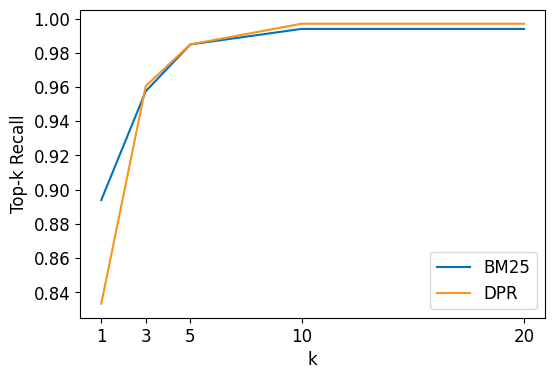

In [60]:
# Evaluamos y hacemos gráfico

dpr_topk_df = evaluate_retriever(dpr_retriever)
plot_retriever_eval([bm25_topk_df, dpr_topk_df], ["BM25", "DPR"])

### Evaluating the Reader

In [61]:
from haystack.modeling.evaluation.squad import compute_f1, compute_exact

pred = "about 6000 hours"
label = "6000 hours"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.8


In [62]:
pred = "about 6000 dollars"
print(f"EM: {compute_exact(label, pred)}")
print(f"F1: {compute_f1(label, pred)}")

EM: 0
F1: 0.4


The evaluation of a reader can be done by creating a pipeline that consists only of a single node: a reader. In this case, the `pipeline.eval()` gets the relevant documents as direct input from the labels.

Antes estaba así

from haystack.pipelines import Pipeline
# Importamos la clase genérica Pipeline (No ExtractiveQAPipeline) porque queremos
# Construir un pipeline con un único componente (el reader)

def evaluate_reader(reader): # la función recibe un reader
    score_keys = ['exact_match', 'f1'] # lista con las métricas que queremos. calculate_metrics() devulve más pero nos quedamos con éstas
    p = Pipeline() # se crea una pipeline vacía
    p.add_node(component=reader, name="Reader", inputs=["Query"])
    # Añade el Reader como único nodo de la pipeline.
    # name="Reader" el nodo se llamrá Reader. Después las métricas-> metrics["Reader"]
    # inputs=["Query"] -> el Reader es el primer nodo que recibe la consulta

    eval_result = p.eval(
        labels=labels_agg, # proporciona el solucionario .labels -> Preguntas, Respuestas correctas, Docs correctos, Metadatos
        documents= [[label.document for label in multilabel.labels] for multilabel in labels_agg],
        params={},
    )
    # for multilabel in labels_agg -> recorre las preguntas agrupadas
    # cada multilabel puede tener varios labels -> una pregunta puede tener varias respuestas válidas o docuemntos asociados
    # [label.document for label in multilabel.labels] Para una pregunta correcta, recorre todos sus lables y extra el documento de cada uno
    #  params={} -> No se pasan parámetros adicionales a los nodos
    
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
    # Calcula las métricas agregadas 
    # simulated_top_k_reader=1 -> Evalúa como si el Reader devolviera únicamente su respuesta mejor puntuada. La de mayor score
    return {k:v for k,v in metrics["Reader"].items() if k in score_keys}

reader_eval = {} # Crea un diccionario vacío que almacenará los resultados de distintos Readers.
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader) # y guarda el resultado bajo el nombre:

In [63]:
from haystack.pipelines import Pipeline
# Importamos la clase genérica Pipeline (No ExtractiveQAPipeline) porque queremos
# Construir un pipeline con un único componente (el reader)

def evaluate_reader(reader): # la función recibe un reader
    score_keys = ['exact_match', 'f1'] # lista con las métricas que queremos. calculate_metrics() devulve más pero nos quedamos con éstas
    p = Pipeline() # se crea una pipeline vacía
    p.add_node(component=reader, name="Reader", inputs=["Query"])
    # Añade el Reader como único nodo de la pipeline.
    # name="Reader" el nodo se llamrá Reader. Después las métricas-> metrics["Reader"]
    # inputs=["Query"] -> el Reader es el primer nodo que recibe la consulta

    labels_small = labels_agg[:5]
    eval_result = p.eval(
        labels=labels_small, # proporciona el solucionario .labels -> Preguntas, Respuestas correctas, Docs correctos, Metadatos
        documents= [[label.document for label in multilabel.labels] for multilabel in labels_small],
        params={},
    )
    # for multilabel in labels_agg -> recorre las preguntas agrupadas
    # cada multilabel puede tener varios labels -> una pregunta puede tener varias respuestas válidas o docuemntos asociados
    # [label.document for label in multilabel.labels] Para una pregunta correcta, recorre todos sus lables y extra el documento de cada uno
    #  params={} -> No se pasan parámetros adicionales a los nodos
    
    metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
    # Calcula las métricas agregadas 
    # simulated_top_k_reader=1 -> Evalúa como si el Reader devolviera únicamente su respuesta mejor puntuada. La de mayor score
    return {k:v for k,v in metrics["Reader"].items() if k in score_keys}

reader_eval = {} # Crea un diccionario vacío que almacenará los resultados de distintos Readers.
reader_eval["Fine-tune on SQuAD"] = evaluate_reader(reader) # y guarda el resultado bajo el nombre:

In the first version no_answer labels weren't taken into account. Because there are quite many of them in the evaluation dataset the numbers differ significantly compared to the first version (EM was at ~0.07 and f1 at ~0.25).

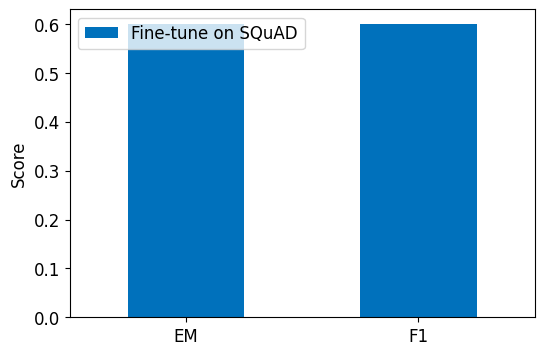

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)
ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [64]:
def plot_reader_eval(reader_eval):
    fig, ax = plt.subplots()
    df = pd.DataFrame.from_dict(reader_eval).reindex(["exact_match", "f1"])
    df.plot(kind="bar", ylabel="Score", rot=0, ax=ax)
    ax.set_xticklabels(["EM", "F1"])
    plt.legend(loc='upper left')
    plt.show()

plot_reader_eval(reader_eval)

Recordemos que 

reader = FARMReader(model_name_or_path=model_ckpt, progress_bar=False,
                    max_seq_len=max_seq_length, doc_stride=doc_stride, 
                    return_no_answer=True)

model_ckpt-> Squad

### Domain Adaptation

Queremos **adaptar el `Reader` al dominio de SubjQA**

El objetivo es adaptar el `Reader` desde el dominio general con el que fue entrenado hacia el dominio concreto de **SubjQA**.

Hasta ahora se estaba utilizando un `Reader` ajustado con **SQuAD**, pero ambos datasets pertenecen a dominios distintos.

```text
SQuAD
────────────────────
Wikipedia
Texto relativamente formal
Preguntas factuales
Respuestas objetivas
```

```text
SubjQA
────────────────────
Reseñas de productos
Texto informal
Opiniones y experiencias
Respuestas frecuentemente subjetivas
```

Por tanto, aunque el modelo ya sabe realizar tareas de *Question Answering*, necesita un ajuste adicional para adaptarse al estilo, vocabulario y tipo de respuestas presentes en SubjQA.

<img alt="SQuAD Schema" caption="Visualization of the SQuAD JSON format" src="images/chapter07_squad-schema.png" id="squad-schema"/>

In [66]:
dfs["train"].head()


,domain,nn_mod,nn_asp,query_mod,query_asp,q_reviews_id,question_subj_level,ques_subj_score,is_ques_subjective,review_id,id,title,context,question,answers.text,answers.answer_start,answers.answer_subj_level,answers.ans_subj_score,answers.is_ans_subjective,n_tokens
0,electronics,great,bass response,excellent,bass,0514ee34b672623dff659334a25b599b,5,0.50,False,882b1e2745a4779c8f17b3d4406b91c7,2543d296da9766d8d17d040ecc781699,B00001P4ZH,"I have had Koss headphones in the past, Pro 4AA and QZ-99. The Koss Portapr...",How is the bass?,[],[],[],[],[],155
1,electronics,harsh,high,not strong,bass,7c46670208f7bf5497480fbdbb44561a,1,0.50,False,ce76793f036494eabe07b33a9a67288a,d476830bf9282e2b9033e2bb44bbb995,B00001P4ZH,"To anyone who hasn't tried all the various types of headphones, it is import...",Is this music song have a goo bass?,"[Bass is weak as expected, Bass is weak as expected, even with EQ adjusted up]","[1302, 1302]","[1, 1]","[0.5083333, 0.5083333]","[True, True]",537
2,electronics,neutral,sound,present,bass,8fbf26792c438aa83178c2d507af5d77,1,0.50,False,d040f2713caa2aff0ce95affb40e12c2,455575557886d6dfeea5aa19577e5de4,B00001P4ZH,"I have had many sub-$100 headphones from $5 Panasonic to $100 Sony, with Sen...",How is the bass?,[The only fault in the sound is the bass],[650],[2],[0.6333333],[True],534
3,electronics,muddy,bass,awesome,bass,9876fd06ed8f075fcad70d1e30e7e8be,1,0.50,False,043e7162df91f6ea916c790c8a6f6b22,6895a59b470d8feee0f39da6c53a92e5,B00001WRSJ,"My sister's Bose headphones finally died and so, her being a super audiophil...",How is the audio bass?,[the best of all of them],[1609],[1],[0.3],[False],440
4,electronics,perfect,bass,incredible,sound,16506b53e2d4c2b6a65881d9462256c2,1,0.65,True,29ccd7e690050e2951be49289e915382,7a2173c502da97c5bd5950eae7cd7430,B00001WRSJ,Wow. Just wow. I'm a 22 yr old with a crazy obsession with sound and music. ...,Why do I have an incredible sound?,"[The sound is so crisp, crazy obsession with sound and music]","[141, 38]","[1, 1]","[0.40833333, 0.40833333]","[False, False]",175


```text
Contenido: SubjQA
Formato original: DataFrame
          ↓
create_paragraphs()
          ↓
Contenido: sigue siendo SubjQA
Formato: parecido a SQuAD
```

`create_paragraphs()` no cambia el contenido del dataset.

Lo que hace es **reorganizar SubjQA en un formato similar al de SQuAD**, que es el formato que saben leer **Haystack/FARM**.

```text
SubjQA
│
├── mismo contenido
│
└── nueva estructura compatible con SQuAD
         │
         ▼
    Haystack/FARM
```

In [69]:
# Esta función transforma un DataFrame de SubjQA en la estructura tipo SQuAD que necesita Haystack para entrenar el Reader.

def create_paragraphs(df): # La función recibe un DataFrame (df)
    # este df contiene filas con info como review_id, context, id, question, answers.text, answer.answer_start
    # la función quiere transformar esas filas en una estructura anidada como esta

   # [
   # {
 #    "context": "...",
    #    "qas": [
     #       {
      #          "question": "...",
       #         "id": "...",
        #        "is_impossible": False,
         #       "answers": [...]
          #  }
      #  ]
   #   }
   #]

    


    
    paragraphs = [] # se crea la lista donde se guardará el resultado.
    id2context = dict(zip(df["review_id"], df["context"])) # relacionamos cada reseña con su contexto
        # df["review_id"] # obtiene columna de identificadores ["r1", "r1","r2"]
        # df["context"] # obtiene la columna de contextos ["This keyboard is very light...", "battery lasts all day...]
        # zip() empareja ambas columnas -> [("r1", "This keyboard is very light..."),("r2", "battery lasts all day..."]
        # dict() conviuerte parejas en dicc-> {"r1":"This keyboard is very light...","r2":"battery lasts all day..."}
        # si r1 se repitiese, ya sólo saldría una vez -> diccionario
    
    for review_id, review in id2context.items(): # recorre cada contexto
        
       # En cada iteración se construirá un bloque completo:{"context": review,"qas": [...]}
        
        qas = [] # crea una lista vacía para las preguntas del contexto actual
        # Filter for all question-answer pairs about a specific context
        review_df = df.query(f"review_id == '{review_id}'") # filtra las filas de la reseña actual ( por ejemplo "r1"-> selcciona filas del contexto r1)
           
        
        id2question = dict(zip(review_df["id"], review_df["question"]))# crea un diccionario de preguntas únicas
        # junta question_id ("id") con "question" -> {"q1": "What is its weight?","q2": "Does it have a case?"}
        # diccionario porque  porque una pregunta puede apareceren varias filas si tiene varias respuestas válidas
        
        # Build up the qas array 
        for qid, question in id2question.items(): # Recorre cada pregunta del contexto
            # Filter for a single question ID 
            question_df = df.query(f"id == '{qid}'").to_dict(orient="list") # obtener todas las filas de esa pregunta
            # .to_dict() -> convierte en diccionario 
            # orient = "list" -> cada columna se convierte en una lista, no en series de pandas (dict())
            
            ans_start_idxs = question_df["answers.answer_start"][0].tolist() # extrae las posiciones iniciales
            # question_df["answers.answer_start"] -> por ejemplo [array([17, 17])]
            # question_df["answers.answer_start"][0] -> extrae primer elemento -> array([17, 17])
            # .tolist() -> lo convierte de array a una lista normal -> [17, 17]
            ans_text = question_df["answers.text"][0].tolist() # hace lo mimso pero con el texto
            # ahora tenemos 2 listas paralelas:
                # ans_text = ["very light", "lightweight"]
                # ans_start_idxs = [17, 17]
            # y la correspondencia es 
                # "very light"  → 17
                # "lightweight" → 17

            
            # Fill answerable questions
            if len(ans_start_idxs): # comprobamos si la pregunta tiene respuesta
                answers = [
                    {"text": text, "answer_start": answer_start}
                    for text, answer_start in zip(ans_text, ans_start_idxs)]
                is_impossible = False # la marcamos como respondible
            else: # si no hay respuesta
                answers = []
                is_impossible = True # la marcamos como no respondible
            # Add question-answer pairs to qas0 / Añadimos la pregunta a qas
            qas.append({"question": question, "id": qid, 
                        "is_impossible": is_impossible, "answers": answers})
        # Add context and question-answer pairs to paragraphs
        paragraphs.append({"qas": qas, "context": review})# añadimos el contexto completo a paragraphs
    return paragraphs # la función de veileve a algo así


    



    

La función devolvería algo así

```text
[ ]                          ← Lista de párrafos
│
└── { }                      ← Un párrafo (una reseña)
    │
    ├── "context"
    │
    └── "qas": [ ]           ← Lista de preguntas
            │
            ├── { }          ← Pregunta 1
            │      │
            │      ├── "question"
            │      ├── "id"
            │      ├── "is_impossible"
            │      └── "answers": [ ]   ← Lista de respuestas
            │                  │
            │                  └── { }  ← Una respuesta
            │                         ├── "text"
            │                         └── "answer_start"
            │
            └── { }          ← Pregunta 2
                   │
                   └── "answers": [ ]   ← Lista vacía
```

In [70]:
# aplicamos la función solo a un producto del DF

product = dfs["train"].query("title == 'B00001P4ZH'")
create_paragraphs(product)

[{'qas': [{'question': 'How is the bass?',
    'id': '2543d296da9766d8d17d040ecc781699',
    'is_impossible': True,
    'answers': []}],
  'context': 'I have had Koss headphones in the past, Pro 4AA and QZ-99.  The Koss Portapro is portable AND has great bass response.  The work great with my Android phone and can be "rolled up" to be carried in my motorcycle jacket or computer bag without getting crunched.  They are very light and do not feel heavy or bear down on your ears even after listening to music with them on all day.  The sound is night and day better than any ear-bud could be and are almost as good as the Pro 4AA.  They are "open air" headphones so you cannot match the bass to the sealed types, but it comes close. For $32, you cannot go wrong.'},
 {'qas': [{'question': 'Is this music song have a goo bass?',
    'id': 'd476830bf9282e2b9033e2bb44bbb995',
    'is_impossible': False,
    'answers': [{'text': 'Bass is weak as expected', 'answer_start': 1302},
     {'text': 'Bass i

In [71]:
# Si create_paragraphs() convertía un DataFrame al formato SQuAD, 
# convert_to_squad() convierte todo el dataset (train, validation y test) y lo guarda en archivos JSON.

import json # módulo estándar de Python para trabajar con archivos JSON

def convert_to_squad(dfs): # dfs es un diccionario q contiene DataFrame
    for split, df in dfs.items():
        subjqa_data = {}
        # Create `paragraphs` for each product ID
        groups = (df.groupby("title").apply(create_paragraphs).to_frame(name="paragraphs").reset_index())
        # df.groupby("title") -> agrupo todoas las filas por producto
        #.apply(create_paragraphs) ->para cada grupo -> create_paragraphs(grupo)
        #.to_frame(name="paragraphs") -> create_paragraph crea una serie, con esto los convertimos a un DF cuya columna se llamará "paragraph".
        #.reset_index() -> después del groupby, text pasa a ser el índice -> esto lo convierte en una columna normal
        subjqa_data["data"] = groups.to_dict(orient="records") # convierte ese DF en una lista de diccionarios y lo guarda bajo lave "data"
            # (orient="records") -> cada fila se convierte en un diccionario
        # Save the result to disk
        with open(f"electronics-{split}.json", "w+", encoding="utf-8") as f:
            json.dump(subjqa_data, f)# escribe el diccionario en formato json
            # "w+"-> crea el archivo si no existe
            
convert_to_squad(dfs)

```text
dfs
│
├── train
├── validation
└── test
        │
        ▼
Recorrer cada DataFrame
        │
        ▼
Agrupar por producto (`title`)
        │
        ▼
create_paragraphs()
        │
        ▼
Formato SQuAD
        │
        ▼
Guardar como JSON
        │
        ▼
electronics-train.json
electronics-validation.json
electronics-test.json
```

Ya hemos terminado la parte de preparación de datos. Ahora **empieza el fine-tuning del Reader**

In [76]:
train_filename = "electronics-train.json" # conjutno de entrenamiento
dev_filename = "electronics-validation.json" # conjunto de validación

reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename, num_processes=1)
# data_dir="." -> los archivos están en el directorio actual

INFO - haystack.modeling.utils -  Using devices: CUDA
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.data_handler.data_silo -  
Loading data into the data silo ... 
              ______
               |o  |   !
   __          |:`_|---'-.
  |__|______.-/ _ \-----.|       
 (o)(o)------'\ _ /     ( )      
 
INFO - haystack.modeling.data_handler.data_silo -  LOADING TRAIN DATA
INFO - haystack.modeling.data_handler.data_silo -  ==================
INFO - haystack.modeling.data_handler.data_silo -  Loading train set from: electronics-train.json 
INFO - haystack.modeling.data_handler.data_silo -  Multiprocessing disabled, using a single worker to convert 1265dictionaries to pytorch datasets.
Preprocessing Dataset electronics-train.json: 100%|█████████████████████████| 1265/1265 [00:00<00:00, 12610.15 Dicts/s]WARNING - haystack.modeling.data_handler.processor -  Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from

```text
Reader.train()

Leer electronics-train.json
            │
            ▼
Extraer preguntas y respuestas
            │
            ▼
Entrenar el Reader durante 1 época
            │
            ▼
Después de cada cierto tiempo
            │
            ▼
Evaluar sobre
electronics-validation.json
```

In [78]:
# evaluamos el modelo. Llamamos a esta evaluación "Fine-tune on SQuAD + SubjQA"
reader_eval["Fine-tune on SQuAD + SubjQA"] = evaluate_reader(reader)

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


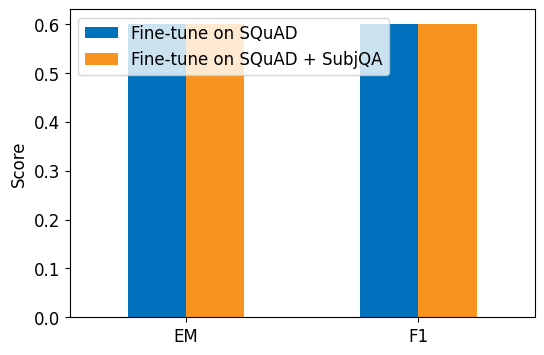

In [79]:
plot_reader_eval(reader_eval)

In [80]:
# Ahora usamos un modelo que NO viene ya preparado específicamente como Reader de question answering sobre SQuAD.
# Quiere probar un enfoque más ingenuo:
    # antes partí de deepset/minilm-uncased-squad2, que ya estaba entrenado para QA con SQuAD;
    # ahora parto de microsoft/MiniLM-L12-H384-uncased, un modelo lingüístico base;
    # después lo ajustarán directamente sobre SubjQA.

# comparamos dos estrategias:
# MiniLM → SQuAD → SubjQA vs MiniLM → SubjQA

minilm_ckpt = "microsoft/MiniLM-L12-H384-uncased"
minilm_reader = FARMReader(model_name_or_path=minilm_ckpt, progress_bar=False,
                           max_seq_len=max_seq_length, doc_stride=doc_stride,
                           return_no_answer=True)

INFO - haystack.modeling.utils -  Using devices: CUDA:0
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.model.language_model -  LOADING MODEL
INFO - haystack.modeling.model.language_model -  =============
INFO - haystack.modeling.model.language_model -  Could not find microsoft/MiniLM-L12-H384-uncased locally.
INFO - haystack.modeling.model.language_model -  Looking on Transformers Model Hub (in local cache and online)...


Downloading:   0%|          | 0.00/385 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/127M [00:00<?, ?B/s]

INFO - haystack.modeling.model.language_model -  Loaded microsoft/MiniLM-L12-H384-uncased


Downloading:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

Downloading: 0.00B [00:00, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

INFO - haystack.modeling.utils -  Using devices: CUDA
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.infer -  Got ya 23 parallel workers to do inference ...
INFO - haystack.modeling.infer -   0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0     0  
INFO - haystack.modeling.infer -  /w\   /w\   /w\   /w\   /w\   /w\   /w\   /|\  /w\   /w\   /w\   /w\   /w\   /w\   /|\  /w\   /|\  /|\  /|\  /|\  /w\   /w\   /|\
INFO - haystack.modeling.infer -  /'\   / \   /'\   /'\   / \   / \   /'\   /'\   /'\   /'\   /'\   /'\   / \   /'\   /'\   / \   /'\   /'\   /'\   /'\   / \   / \   /'\ 
ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [81]:
minilm_reader.train(data_dir=".", use_gpu=True, n_epochs=1, batch_size=16,
             train_filename=train_filename, dev_filename=dev_filename, num_processes=1)

INFO - haystack.modeling.utils -  Using devices: CUDA
INFO - haystack.modeling.utils -  Number of GPUs: 1
INFO - haystack.modeling.data_handler.data_silo -  
Loading data into the data silo ... 
              ______
               |o  |   !
   __          |:`_|---'-.
  |__|______.-/ _ \-----.|       
 (o)(o)------'\ _ /     ( )      
 
INFO - haystack.modeling.data_handler.data_silo -  LOADING TRAIN DATA
INFO - haystack.modeling.data_handler.data_silo -  ==================
INFO - haystack.modeling.data_handler.data_silo -  Loading train set from: electronics-train.json 
INFO - haystack.modeling.data_handler.data_silo -  Multiprocessing disabled, using a single worker to convert 1265dictionaries to pytorch datasets.
Preprocessing Dataset electronics-train.json: 100%|█████████████████████████| 1265/1265 [00:00<00:00, 12615.03 Dicts/s]WARNING - haystack.modeling.data_handler.processor -  Answer 'These earbuds are nothing special. Their best attribute is that they are cheap. The sound from

In [82]:
reader_eval["Fine-tune on SubjQA"] = evaluate_reader(minilm_reader)

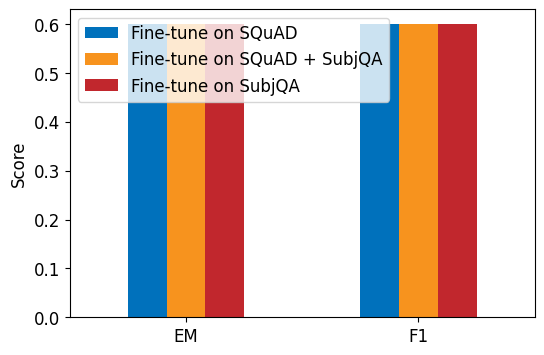

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [83]:
plot_reader_eval(reader_eval)

OJO!!! En el notebook, antes hicimos esta modificación para evitar el problema del multiprocessing. Recuerda que cambiamos la función evaluate_reader() para que no evaluara todo el conjunto, sino solo una parte. Si no recuerdo mal, habíamos reducido el número de ejemplos para que la evaluación no se quedara bloqueada.

### Diferencias con los resultados del libro

En el libro, el modelo **Fine-tune on SubjQA** obtiene un rendimiento claramente inferior al modelo **Fine-tune on SQuAD + SubjQA**. Esto se debe a que **SubjQA es un conjunto de datos relativamente pequeño**.

- **Fine-tune on SQuAD + SubjQA:** el modelo primero aprende la tarea de *Question Answering* con el gran conjunto de datos **SQuAD** y posteriormente se adapta al dominio de las reseñas de productos mediante **SubjQA**.
- **Fine-tune on SubjQA:** el modelo parte de un MiniLM base y debe aprender **la tarea de QA y el nuevo dominio al mismo tiempo**, utilizando únicamente SubjQA.

En mi ejecución las diferencias entre ambos modelos son mucho menores. La causa más probable es que **la evaluación no se realizó exactamente igual que en el libro**, ya que fue necesario modificar el notebook para evitar problemas de compatibilidad (por ejemplo, evaluando un subconjunto de ejemplos y deshabilitando el multiprocessing con `num_processes=1`).

La conclusión del experimento sigue siendo la misma: **partir de un modelo previamente ajustado para Question Answering (SQuAD) suele proporcionar una mejor base para adaptarse a un nuevo dominio que entrenar directamente sobre un conjunto de datos pequeño como SubjQA.**

| Dominio | Tipo de textos |
|---------|-----------------|
| **SQuAD** | Artículos de Wikipedia |
| **SubjQA** | Reseñas de productos, hoteles, libros, películas, etc. |
| **BioASQ** | Artículos biomédicos |
| **Legal QA** | Contratos, leyes y sentencias |
| **Financial QA** | Informes financieros, balances y noticias económicas |

Aunque la tarea sea siempre la misma (Question Answering), el lenguaje cambia mucho entre dominios.

El modelo ya sabe cómo buscar una respuesta (gracias a SQuAD), pero necesita aprender el vocabulario, el estilo de escritura y la forma de expresar la información en ese nuevo dominio.

Por eso el flujo ideal es:

```text
Pretraining
      │
      ▼
Aprender el lenguaje (MiniLM / BERT)

      │
      ▼
Fine-tuning en SQuAD
Aprender la tarea de Question Answering

      │
      ▼
Fine-tuning en SubjQA
Adaptarse al dominio de las reseñas de productos
```

Cada etapa aporta un conocimiento diferente:

| Etapa | Qué aprende el modelo |
|-------|------------------------|
| **Pretraining** | Comprende el lenguaje: gramática, vocabulario y relaciones entre palabras. |
| **Fine-tuning en SQuAD** | Aprende a realizar la tarea de *Question Answering* (localizar el inicio y el final de una respuesta en un texto). |
| **Fine-tuning en SubjQA** | Se adapta al nuevo dominio: reseñas de productos, lenguaje informal, opiniones y respuestas subjetivas. |

### Evaluating the Whole QA Pipeline

In [87]:
!bin/elasticsearch

/bin/bash: line 1: bin/elasticsearch: No such file or directory


In [99]:
from haystack.pipelines import ExtractiveQAPipeline # Esta clase coordina Retriever y Reader
pipe = ExtractiveQAPipeline(retriever=bm25_retriever, reader=reader) # creamos el pipeline

# Evaluate!
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
) # aquí evaluamos todo el sistema
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1) # calculamos métricas de todo el pipeline, no sólo EM y F1
# Extract metrics from reader /sólo las métricas del Reader y las 
reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]} # cogemos sólo EM y f1 del Reader porque ya está afectado por el funcionamiento del Retriever

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)
ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


Solo se almacenan las métricas **EM** y **F1** del Reader porque representan la calidad de la respuesta final que recibe el usuario. Sin embargo, estas métricas **ya están afectadas por el funcionamiento del Retriever**, ya que durante la evaluación del pipeline el Reader no recibe el contexto correcto garantizado, sino los documentos recuperados por el Retriever. Si el Retriever falla, el Reader probablemente también fallará, y sus métricas (EM y F1) disminuirán aunque el problema original esté en la recuperación de documentos.

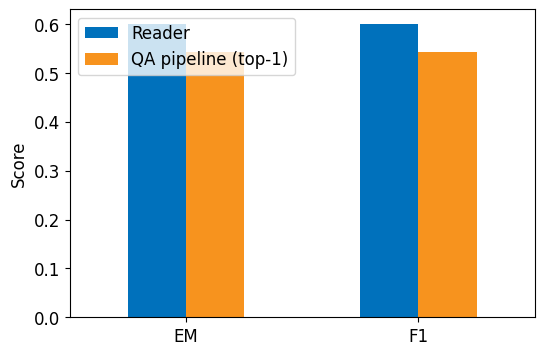

In [100]:
# Quiere comparar Reader sólo vs Pipeline completo
# caption Comparison of EM and _F_~1~ scores for the reader against the whole QA pipeline
plot_reader_eval({"Reader": reader_eval["Fine-tune on SQuAD + SubjQA"], 
                  "QA pipeline (top-1)": reader_eval["QA Pipeline (top-1)"]})

# a Plot_reader_eval() se le pasa un diccionario con dos elementos:
    # "Reader": reader_eval["Fine-tune on SQuAD + SubjQA"] -> resultados del Reader aislado
    # "QA pipeline (top-1)":reader_eval["QA Pipeline (top-1)"] -> resiultadoa del sistema completo
    

Es normal que el Pipeline obtenga peores resultados que el Reader aislado, porque ahora el Reader depende de que el Retriever haya encontrado el documento correcto.

Ese pequeño descenso en EM y F1 representa el "precio" de convertir un modelo de QA en un sistema completo que empieza desde una pregunta del usuario y debe recuperar por sí mismo la información adecuada.

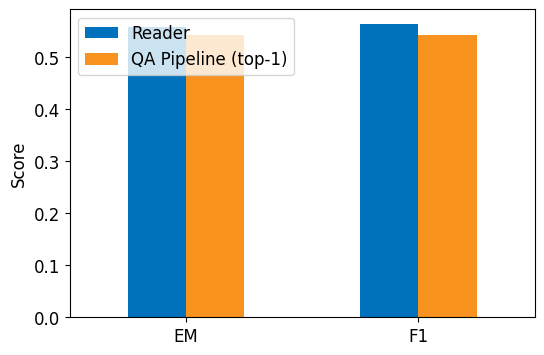

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [101]:
# Or get QA pipeline and Reader metrics in one shot:
# Reader evaluation is run a second time using simulated perfect retriever results
eval_result = pipe.eval(
    labels=labels_agg,
    params={},
    add_isolated_node_eval=True
)
metrics = eval_result.calculate_metrics(simulated_top_k_reader=1)
# Extract metrics from reader run in isolation with simulated perfect retriever
isolated_metrics = eval_result.calculate_metrics(simulated_top_k_reader=1, eval_mode="isolated")

pipeline_reader_eval = {}
pipeline_reader_eval["Reader"] = {
    k:v for k,v in isolated_metrics["Reader"].items()
    if k in ["exact_match", "f1"]}
pipeline_reader_eval["QA Pipeline (top-1)"] = {
    k:v for k,v in metrics["Reader"].items()
    if k in ["exact_match", "f1"]}

plot_reader_eval(pipeline_reader_eval)

Haystack añade una segunda evaluación del Reader.

En esa segunda evaluación, simula (con add_isolated_node_eval=True) que el Retriever ha funcionado perfectamente y entrega al Reader los documentos correctos de las etiquetas.

## Going Beyond Extractive QA

<img alt="RAG Architecture" width="600" caption="The RAG architecture for fine-tuning a retriever and generator end-to-end (courtesy of Ethan Perez)" src="images/chapter07_rag-architecture.png" id="rag"/>

### Retrieval-Augmented Generation

In [102]:
from haystack.nodes import RAGenerator
# RAGenerator es el nodo de Haystack que implementa el modelo RAG (Retrieval-Augmented Generation)
generator = RAGenerator(model_name_or_path="facebook/rag-token-nq",
                        embed_title=False, num_beams=5)
# Carga este modelo de Hugging Face
# nq -> Natural Questions: conjunto de datos de Google con preguntas reales 
                        # formuladas por usuarios y respuestas obtenidas de Wikipedia.
# embed_title=False -> Hace embeddings del contendido no del título + contenido
# num_beams=5 # beam search con 5 palabras

INFO - haystack.modeling.utils -  Using devices: CUDA
INFO - haystack.modeling.utils -  Number of GPUs: 1


Downloading: 0.00B [00:00, ?B/s]

/home/srmjf/qa/lib/python3.9/site-packages/transformers/models/bart/configuration_bart.py:179: UserWarning: Please make sure the config includes `forced_bos_token_id=0` in future versions. The config can simply be saved and uploaded again to be fixed.
  warnings.warn(


Downloading: 0.00B [00:00, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Downloading: 0.00B [00:00, ?B/s]

Downloading:   0%|          | 0.00/772 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/1.92G [00:00<?, ?B/s]

ERROR - posthog -  error uploading: [PostHog] <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
</body>
</html>
 (504)


In [108]:
from haystack.pipelines import GenerativeQAPipeline

# antes usábamos ExtractiveQAPipeline

# creamos el pipeline

pipe = GenerativeQAPipeline(generator=generator, retriever=dpr_retriever)

In [120]:
document_store.update_embeddings(
    retriever=dpr_retriever
)

INFO - haystack.document_stores.elasticsearch -  Updating embeddings for all 1615 docs ...


Updating embeddings:   0%|          | 0/1615 [00:00<?, ? Docs/s]

Create embeddings:   0%|          | 0/1616 [00:00<?, ? Docs/s]

In [121]:
def generate_answers(query, top_k_generator=3):
    #query -> pregunta que hará el usuario
    #top_k_generator: cuántas respuestas queremos que genere el modelo.
    preds = pipe.run(query=query, 
                     params={"Retriever": {"top_k":5, # Cada nodo puede recibir sus propios parámetros.Primero se configuran los del Retriever.
                                  "filters":{"item_id": ["B0074BW614"]}},# filtros: Solo busca documentos cuyo item_id = B0074BW614
                             "Generator": {"top_k": top_k_generator}})  
    print(f"Question: {preds['query']} \n")
    for idx in range(top_k_generator):
        print(f"Answer {idx+1}: {preds['answers'][idx].answer}") # Imprime las 3 respuestas

In [122]:
document_store.get_document_count()

1615

In [123]:
generate_answers(query)

/home/srmjf/qa/lib/python3.9/site-packages/transformers/models/rag/tokenization_rag.py:92: FutureWarning: `prepare_seq2seq_batch` is deprecated and will be removed in version 5 of 🤗 Transformers. Use the regular `__call__` method to prepare your inputs and the tokenizer under the `with_target_tokenizer` context manager to prepare your targets. See the documentation of your specific tokenizer for more details
  warnings.warn(
/home/srmjf/qa/lib/python3.9/site-packages/transformers/generation_utils.py:2129: UserWarning: `max_length` is deprecated in this function, use `stopping_criteria=StoppingCriteriaList(MaxLengthCriteria(max_length=max_length))` instead.
  warnings.warn(


Question: Is it good for reading?

Answer 1:  the screen is absolutely beautiful
Answer 2:  the Screen is absolutely beautiful
Answer 3:  Kindle fire


In [124]:
generate_answers("What is the main drawback?")

Question: What is the main drawback?

Answer 1:  the price
Answer 2:  no flash support
Answer 3:  the cost


## Conclusion

<img alt="QA Pyramid" caption="The QA hierarchy of needs" src="images/chapter07_qa-pyramid.png" id="qa-pyramid"/> 